# Desafio SCTEC por Matheus Henrique França

In [71]:
# Importação das bibliotecas básicas de manipulação de dados
import pandas as pd
import numpy as np

# Importação das bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Importação das ferramentas de Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, roc_curve

# Configurações de visualização
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## Dicionário de Colunas


Abaixo está a descrição das variáveis(colunas) presentes no dataset:

<br>

| Coluna | Descrição |
| :--- | :--- |
| `hotel` | Tipo de Hotel (H1 = Resort Hotel ou H2 = City Hotel [Hotel Urbano]). |
| `is_canceled` | Valor indicando se a reserva foi cancelada (1) ou não (0). |
| `lead_time` | Número de dias decorridos entre a data de inserção da reserva no sistema (PMS) e a data de chegada. |
| `arrival_date_year` | Ano da data de chegada. |
| `arrival_date_month` | Mês da data de chegada. |
| `arrival_date_week_number` | Número da semana do ano correspondente à data de chegada. |
| `arrival_date_day_of_month` | Dia do mês da data de chegada. |
| `stays_in_weekend_nights` | Número de noites de fim de semana (sábado ou domingo) que o hóspede ficou ou reservou para ficar no hotel. |
| `stays_in_week_nights` | Número de noites de dias úteis (segunda a sexta-feira) que o hóspede ficou ou reservou para ficar no hotel. |
| `adults` | Número de adultos. |
| `children` | Número de crianças. |
| `babies` | Número de bebês. |
| `meal` | Tipo de refeição reservada. As categorias seguem os pacotes padrão de hospitalidade: **Undefined/SC** – sem pacote de refeição; **BB** – Bed & Breakfast (Café da manhã); **HB** – Half board (Meia-pensão: café da manhã e uma outra refeição, geralmente jantar); **FB** – Full board (Pensão completa: café da manhã, almoço e jantar). |
| `country` | País de origem. As categorias são representadas no formato ISO 3155–3:2013. |
| `market_segment` | Designação do segmento de mercado. Nas categorias, o termo "TA" significa "Travel Agents" (Agentes de Viagem) e "TO" significa "Tour Operators" (Operadores Turísticos). |
| `distribution_channel` | Canal de distribuição da reserva. O termo "TA" significa "Travel Agents" (Agentes de Viagem) e "TO" significa "Tour Operators" (Operadores Turísticos). |
| `is_repeated_guest` | Valor indicando se a reserva foi feita por um hóspede recorrente (1) ou não (0). |
| `previous_cancellations` | Número de reservas anteriores que foram canceladas pelo cliente antes da reserva atual. |
| `previous_bookings_not_canceled` | Número de reservas anteriores não canceladas pelo cliente antes da reserva atual. |
| `reserved_room_type` | Código do tipo de quarto reservado. O código é apresentado no lugar da designação real por motivos de anonimato. |
| `assigned_room_type` | Código do tipo de quarto atribuído à reserva. Às vezes, o tipo atribuído difere do reservado devido a razões operacionais do hotel (ex: overbooking) ou a pedido do cliente. O código é apresentado no lugar da designação real por motivos de anonimato. |
| `booking_changes` | Número de alterações/emendas feitas na reserva desde o momento em que ela foi inserida no sistema (PMS) até o momento do check-in ou cancelamento. |
| `deposit_type` | Indicação se o cliente fez um depósito para garantir a reserva. Três categorias possíveis: **No Deposit** – nenhum depósito foi feito; **Non Refund** – depósito feito no valor total da estadia; **Refundable** – depósito feito com um valor inferior ao custo total da estadia. |
| `agent` | ID da agência de viagens que fez a reserva. |
| `company` | ID da empresa/entidade que fez a reserva ou responsável por pagá-la. O ID é apresentado no lugar do nome real por motivos de anonimato. |
| `days_in_waiting_list` | Número de dias em que a reserva permaneceu na lista de espera antes de ser confirmada para o cliente. |
| `customer_type` | Tipo de reserva, assumindo uma de quatro categorias: **Contract** - reserva com contrato ou cota associada; **Group** – reserva associada a um grupo; **Transient** – reserva que não faz parte de grupo ou contrato e não está associada a outra reserva; **Transient-party** – reserva transitória, mas que está associada a pelo menos uma outra reserva transitória. |
| `adr` | Tarifa Diária Média (Average Daily Rate), calculada dividindo a soma de todas as transações de hospedagem pelo número total de noites de estadia. |
| `required_car_parking_spaces` | Número de vagas de estacionamento exigidas pelo cliente. |
| `total_of_special_requests` | Número de pedidos especiais feitos pelo cliente (ex: cama de solteiro extra, andar alto). |
| `reservation_status` | Último status da reserva, assumindo uma de três categorias: **Canceled** – cancelada pelo cliente; **Check-Out** – cliente fez o check-in e já partiu; **No-Show** – cliente não fez o check-in e informou o hotel o motivo. |
| `reservation_status_date` | Data em que o último status foi definido. Esta variável pode ser usada em conjunto com o `reservation_status` para identificar o momento do cancelamento ou check-out. |

## Carregamento e Inspeção Inicial

In [3]:
# Carregando os dados
# OBS: O arquivo CSV deverá ter sido inserido na pasta 'sample_data' do ambiente do google colab
df = pd.read_csv('hotel_bookings.csv')

In [4]:
# Exibindo as 5 primeiras linhas
display(df.head())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
# Verificando as informações das colunas, contagem de não-nulos e tipos de dados
print("\n--- Informações do Dataset ---")
df.info()


--- Informações do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-nul

In [10]:
# Verificando os valores nulos
print("--- Contagem de Valores Nulos ---\n")
print(df.isnull().sum()[df.isnull().sum() > 0])

--- Contagem de Valores Nulos ---

children         4
country        488
agent        16340
company     112593
dtype: int64


## Tratamento de Dados (Pré-processamento)

### 1. Tratamento de Valores Nulos

In [11]:
# Removendo a coluna 'company' pois tem mais de 90% de valores nulos

df.drop('company', axis=1, inplace=True)

In [14]:
# Preenchendo as linhas com valores nulhos da coluna 'agent' com 0
# (indicando que não houve agente)

df['agent'].fillna(0, inplace=True)

In [15]:
# Preenchendo os valores nulos da coluna 'children' com 0

df['children'].fillna(0, inplace=True)

In [88]:
# Preenchendo 'country' nulos com 'Unknown' (Desconhecido)

df['country'].fillna('Unknown', inplace=True)

### 2. Convertendo tipos de dados

In [16]:
# Convertendo para inteiro os valores das colunas 'children' e 'agent'
# que inicialmente estão no padrão float

df['children'] = df['children'].astype(int)

df['agent'] = df['agent'].astype(int)

### 3. Tratamento de Outliers

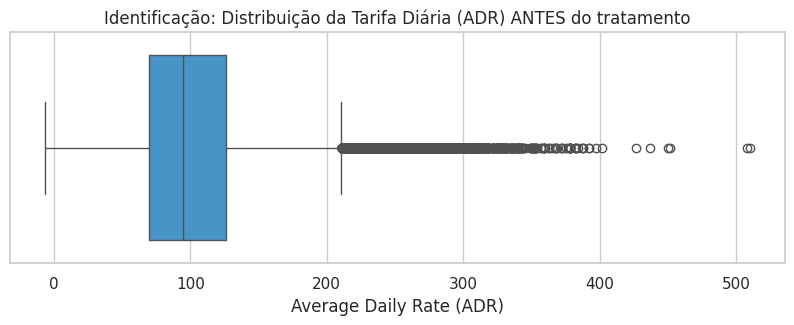

In [84]:
# Gerando um gráfico Boxplot para identificar outliers

plt.figure(figsize=(10, 3))
sns.boxplot(x=df['adr'], color='#3498db')
plt.title('Identificação: Distribuição da Tarifa Diária (ADR) ANTES do tratamento', fontsize=12)
plt.xlabel('Average Daily Rate (ADR)')
plt.show()

In [86]:
# Verificando o valor máximo antes da limpeza

max_adr_antes = df['adr'].max()
print(f"O valor máximo encontrado na tarifa diária foi de ${max_adr_antes:.2f}.")

O valor máximo encontrado na tarifa diária foi de $510.00.


In [18]:
# Existe um registro de outlier no ADR (Tarifa Média) que ultrapassa 5000. Vamos removê-lo.

df = df[df['adr'] < 5000]

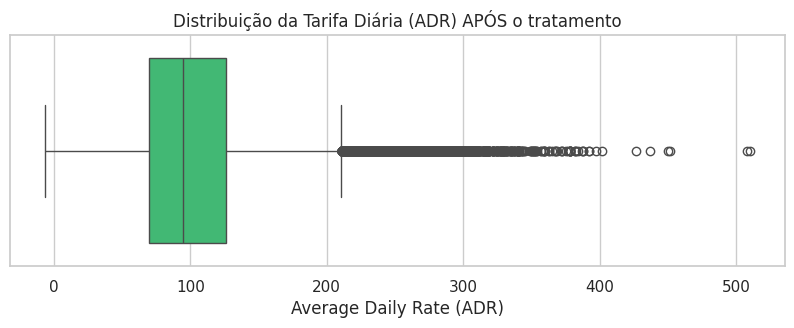

In [87]:
# Gerando um gráfico Boxplot APÓS o tratamento para garantir que a distribuição normalizou
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['adr'], color='#2ecc71')
plt.title('Distribuição da Tarifa Diária (ADR) APÓS o tratamento', fontsize=12)
plt.xlabel('Average Daily Rate (ADR)')
plt.show()

### 4. Limpeza lógica

In [17]:
# Removendo linhas que a reserva possui 0 adultos, 0 crianças e 0 bebês

filtro_sem_hospedes = (df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)
df = df[~filtro_sem_hospedes]

In [21]:
print(f"Dimensões do dataset após limpeza: {df.shape}")

Dimensões do dataset após limpeza: (119209, 31)


## Análise Exploratória de Dados (EDA)

In [59]:
# Configurando as cores padronizadas solicitadas
cor_positiva = '#00ff8860' # Verde (Não Cancelado)
cor_negativa = '#ff000072' # Vermelho (Cancelado)

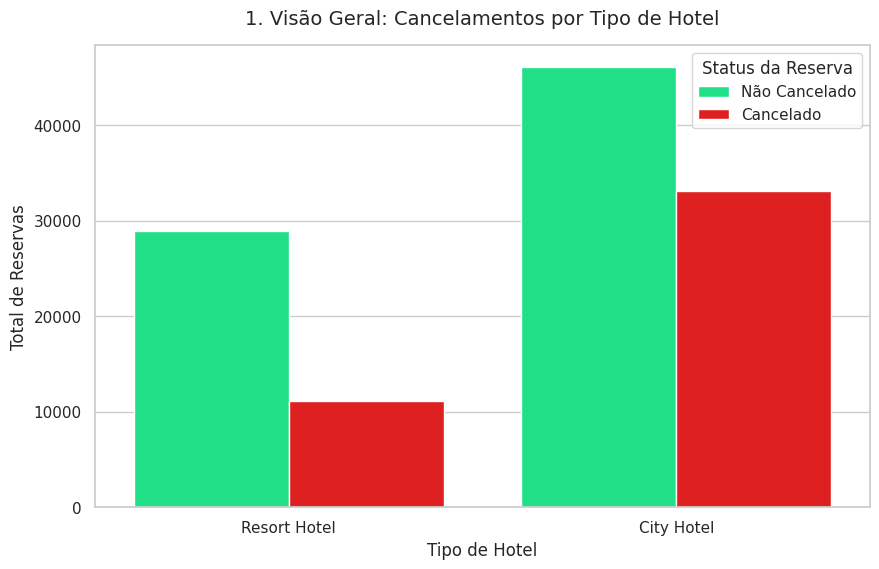

In [60]:
# 1. Visão Geral: Cancelamentos por Tipo de Hotel

plt.figure(figsize=(10, 6))
sns.countplot(x='hotel', hue='is_canceled', data=df, palette={0: cor_positiva, 1: cor_negativa})
plt.title('1. Visão Geral: Cancelamentos por Tipo de Hotel', fontsize=14, pad=15)
plt.xlabel('Tipo de Hotel')
plt.ylabel('Total de Reservas')
plt.legend(title='Status da Reserva', labels=['Não Cancelado', 'Cancelado'])
plt.show()

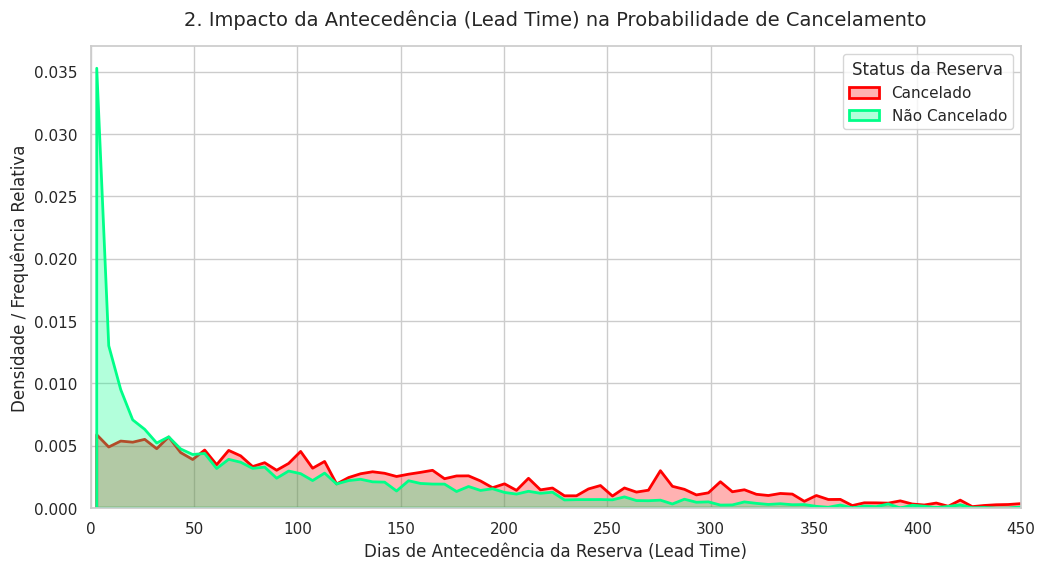

In [61]:
# 2. Impacto da Antecedência (Lead Time)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='lead_time', hue='is_canceled',
             element="poly", stat="density", common_norm=False,
             palette={0: cor_positiva, 1: cor_negativa}, alpha=0.3, linewidth=2)
plt.title('2. Impacto da Antecedência (Lead Time) na Probabilidade de Cancelamento', fontsize=14, pad=15)
plt.xlabel('Dias de Antecedência da Reserva (Lead Time)')
plt.ylabel('Densidade / Frequência Relativa')
plt.legend(title='Status da Reserva', labels=['Cancelado', 'Não Cancelado'])
plt.xlim(0, 450) # Limitando o eixo X para evitar caudas muito longas e vazias
plt.show()

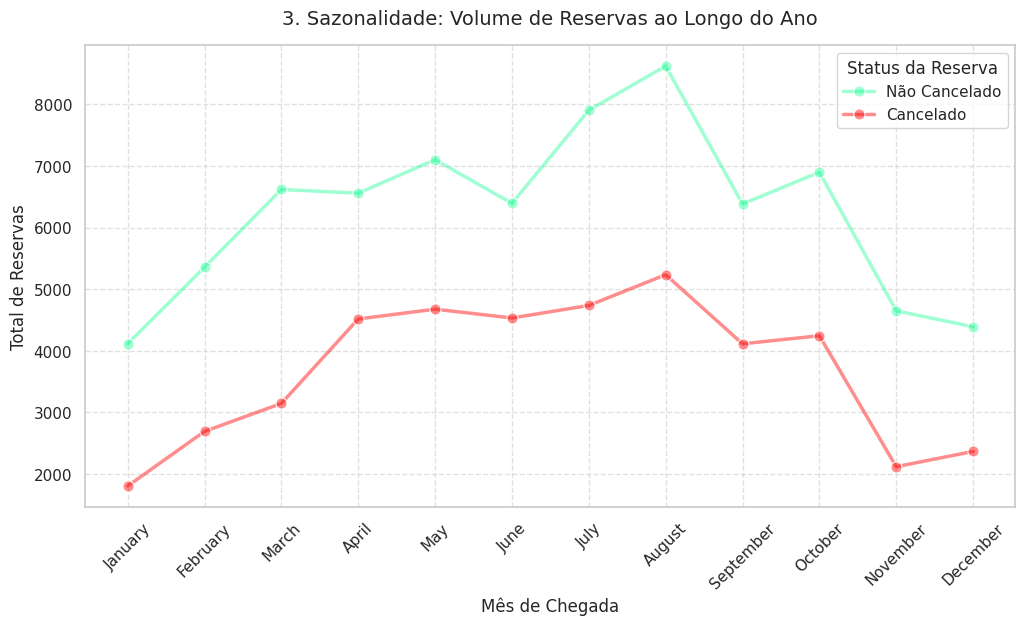

In [62]:
# 3. Sazonalidade (Meses do ano)

meses_ordem = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Agrupando e estruturando os dados para as linhas
sazonalidade = df.groupby(['arrival_date_month', 'is_canceled']).size().unstack().reindex(meses_ordem)
sazonalidade.columns = ['Não Cancelado', 'Cancelado']

plt.figure(figsize=(12, 6))
sns.lineplot(data=sazonalidade['Não Cancelado'], marker='o', label='Não Cancelado', color=cor_positiva, linewidth=2.5, markersize=8)
sns.lineplot(data=sazonalidade['Cancelado'], marker='o', label='Cancelado', color=cor_negativa, linewidth=2.5, markersize=8)
plt.title('3. Sazonalidade: Volume de Reservas ao Longo do Ano', fontsize=14, pad=15)
plt.xlabel('Mês de Chegada')
plt.ylabel('Total de Reservas')
plt.xticks(rotation=45)
plt.legend(title='Status da Reserva')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

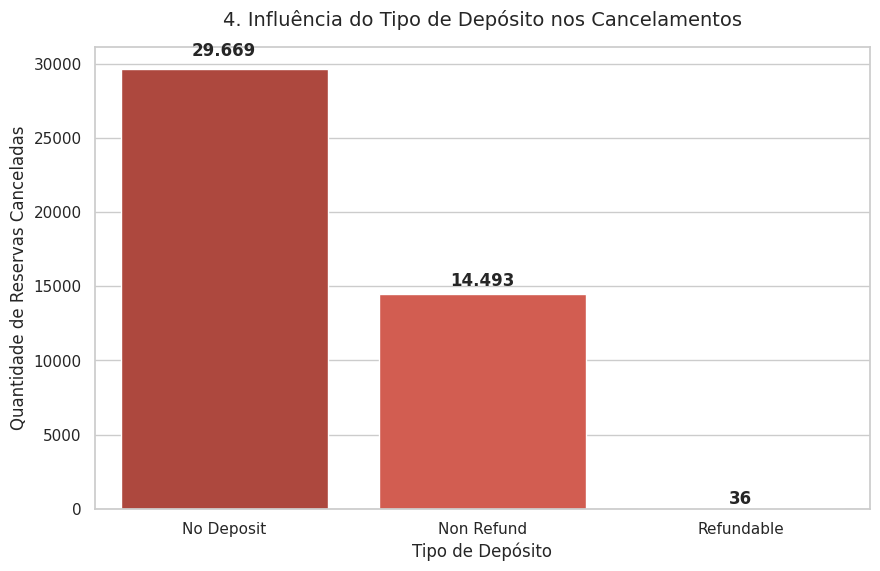

In [63]:
# 4. Influência do Tipo de Depósito

# Filtrando apenas canceladas e contando os valores
cancelados_por_deposito = df[df['is_canceled'] == 1]['deposit_type'].value_counts()

plt.figure(figsize=(10, 6))
# Usando tons de vermelho/laranja para indicar algo negativo (cancelamento)
sns.barplot(x=cancelados_por_deposito.index, y=cancelados_por_deposito.values, palette=['#c0392b', '#e74c3c', '#e67e22'])
plt.title('4. Influência do Tipo de Depósito nos Cancelamentos', fontsize=14, pad=15)
plt.xlabel('Tipo de Depósito')
plt.ylabel('Quantidade de Reservas Canceladas')

# Adicionando os rótulos de dados em cima das barras para clareza
for i, v in enumerate(cancelados_por_deposito.values):
    plt.text(i, v + (v * 0.02), f"{v:,}".replace(',', '.'), ha='center', va='bottom', fontweight='bold')
plt.show()

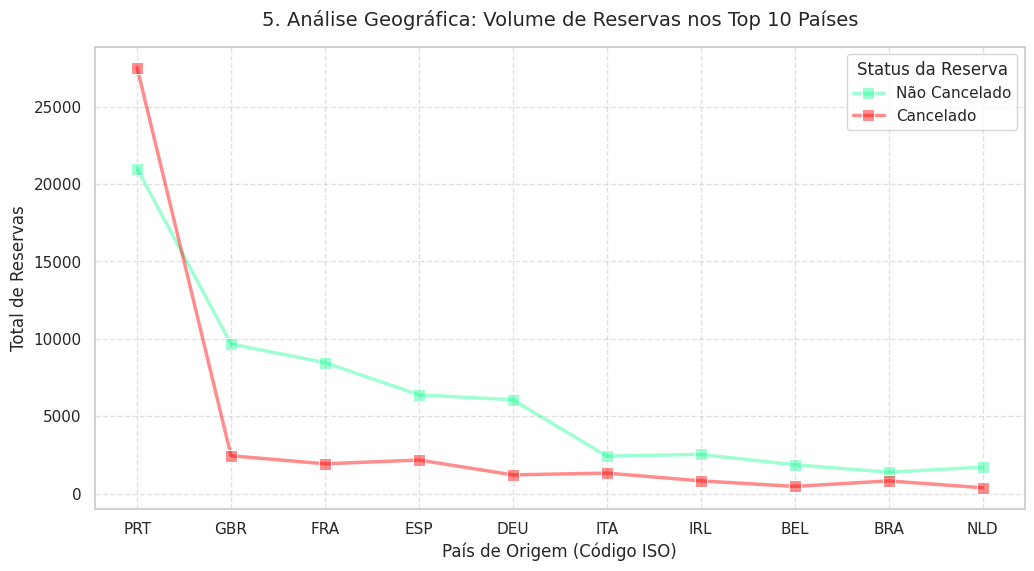

In [64]:
# 5. Análise Geográfica (Top 10 Países)

top10_countries = df['country'].value_counts().head(10).index
geo_data = df[df['country'].isin(top10_countries)].groupby(['country', 'is_canceled']).size().unstack().fillna(0)

# Ordenando o eixo X pelo volume total de reservas para que a linha tenha um fluxo lógico decrescente
geo_data['Total'] = geo_data[0] + geo_data[1]
geo_data = geo_data.sort_values(by='Total', ascending=False)
geo_data.columns = ['Não Cancelado', 'Cancelado', 'Total']

plt.figure(figsize=(12, 6))
sns.lineplot(data=geo_data['Não Cancelado'], marker='s', label='Não Cancelado', color=cor_positiva, linewidth=2.5, markersize=8)
sns.lineplot(data=geo_data['Cancelado'], marker='s', label='Cancelado', color=cor_negativa, linewidth=2.5, markersize=8)
plt.title('5. Análise Geográfica: Volume de Reservas nos Top 10 Países', fontsize=14, pad=15)
plt.xlabel('País de Origem (Código ISO)')
plt.ylabel('Total de Reservas')
plt.legend(title='Status da Reserva')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Feature Engineering

In [42]:
# Criando novas variáveis (Feature Engineering)

df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [43]:
# REMOVENDO VAZAMENTO DE DADOS (Data Leakage)
# Essas variáveis revelam se a pessoa cancelou ou não, o que "enganaria" o modelo preditivo.

df.drop(['reservation_status', 'reservation_status_date'], axis=1, inplace=True)

In [45]:
# Selecionando as variáveis preditoras (X) e a variável alvo (y)

y = df['is_canceled']
X = df.drop('is_canceled', axis=1)

In [46]:
# Codificando variáveis categóricas (Transformando texto em colunas numéricas - One Hot Encoding)

variaveis_categoricas = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=variaveis_categoricas, drop_first=True)

In [47]:
# Dividindo o dataset em conjunto de Treino (80%) e Teste (20%)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [48]:
# Padronizando os dados (importante para a Regressão Logística)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modelagem Preditiva

In [49]:
# ---------------------------------------------
# MODELO 1: RANDOM FOREST (Floresta Aleatória)
# ---------------------------------------------

rf_model = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
rf_model.fit(X_train, y_train) # Treinando o modelo
y_pred_rf = rf_model.predict(X_test) # Fazendo previsões

In [50]:
# ---------------------------------------------
# MODELO 2: REGRESSÃO LOGÍSTICA
# ---------------------------------------------

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train) # Treinando
y_pred_lr = lr_model.predict(X_test_scaled) # Fazendo previsões

## Avaliação e Comparação dos Modelos


In [68]:
# 1. Função para calcular e exibir três métricas:

def calcular_metricas(nome_modelo, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)

    print(f"--- Desempenho: {nome_modelo} ---")
    print(f"1. Acurácia (Accuracy): {acc:.4f} ({(acc*100):.2f}%)")
    print(f"2. Recall (Revocação):  {rec:.4f} ({(rec*100):.2f}%)")
    print(f"3. AUC-ROC:             {auc:.4f} ({(auc*100):.2f}%)\n")
    return acc, rec, auc

In [69]:
# Extraindo as probabilidades (necessárias para o cálculo do AUC-ROC)
# O índice [:, 1] pega a probabilidade da classe 1 (Cancelamento)

y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

In [72]:
# Exibindo os resultados numéricos

print("==================================================")
print("COMPARAÇÃO DE DESEMPENHO DOS MODELOS")
print("==================================================\n")
metricas_rf = calcular_metricas("RANDOM FOREST", y_test, y_pred_rf, y_proba_rf)
metricas_lr = calcular_metricas("REGRESSÃO LOGÍSTICA", y_test, y_pred_lr, y_proba_lr)

COMPARAÇÃO DE DESEMPENHO DOS MODELOS

--- Desempenho: RANDOM FOREST ---
1. Acurácia (Accuracy): 0.8907 (89.07%)
2. Recall (Revocação):  0.8035 (80.35%)
3. AUC-ROC:             0.9588 (95.88%)

--- Desempenho: REGRESSÃO LOGÍSTICA ---
1. Acurácia (Accuracy): 0.8142 (81.42%)
2. Recall (Revocação):  0.6610 (66.10%)
3. AUC-ROC:             0.8952 (89.52%)



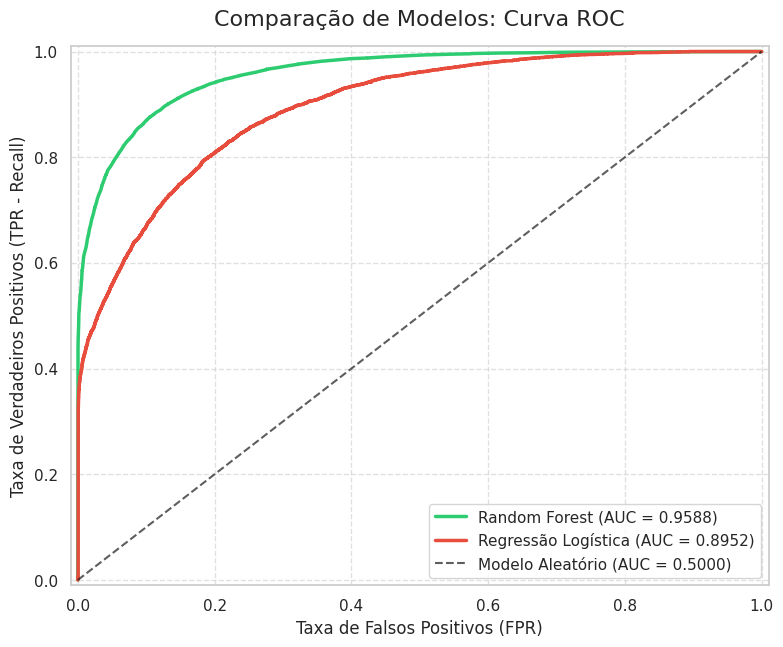

In [77]:
# Gráfico Comparativo: Curva ROC

plt.figure(figsize=(9, 7))

# Calculando as taxas para o gráfico

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

# Plotando as linhas


plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {metricas_rf[2]:.4f})', color='#2ecc71', linewidth=2.5)
plt.plot(fpr_lr, tpr_lr, label=f'Regressão Logística (AUC = {metricas_lr[2]:.4f})', color='#e74c3c', linewidth=2.5)

# Linha de base (Modelo Aleatório)

plt.plot([0, 1], [0, 1], 'k--', label='Modelo Aleatório (AUC = 0.5000)', alpha=0.7)

# Configurações estéticas do gráfico
plt.title('Comparação de Modelos: Curva ROC', fontsize=16, pad=15)
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR - Recall)', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])


plt.show()

In [79]:
# Tabela Resumo
resumo = pd.DataFrame({
    'Métrica': ['Acurácia (Accuracy)', 'Recall (Revocação)', 'AUC-ROC'],
    'Random Forest': [f"{metricas_rf[0]:.4f}", f"{metricas_rf[1]:.4f}", f"{metricas_rf[2]:.4f}"],
    'Regressão Logística': [f"{metricas_lr[0]:.4f}", f"{metricas_lr[1]:.4f}", f"{metricas_lr[2]:.4f}"]
})

print("==================================================")
print("TABELA RESUMO DE COMPARAÇÃO")
print("==================================================")
display(resumo)

TABELA RESUMO DE COMPARAÇÃO


,Métrica,Random Forest,Regressão Logística
0,Acurácia (Accuracy),0.8907,0.8142
1,Recall (Revocação),0.8035,0.6610
2,AUC-ROC,0.9588,0.8952
